In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
trade_history = pd.read_csv('data/processed.csv')

## Hour Based Analysis
Hour based comparison of trade count, PnL mean and sum

In [3]:
hour_stat = trade_history.groupby('hour').agg({
    'Trade ID': 'count',
    'Closed PnL': ['sum','mean']
})

hour_stat

Trade ID     Closed PnL            
        count            sum        mean
hour                                    
0        9856  425052.507901   43.126269
1       10481  523198.626370   49.918770
2        8181  279834.366301   34.205399
3       10524  460020.571385   43.711571
4       10009  444895.598756   44.449555
5        9538  385913.303193   40.460611
6        9057  298730.758694   32.983412
7        8585  712784.325348   83.026712
8        7848  462140.622931   58.886420
9        6548  294525.282383   44.979426
10       6745  413788.812966   61.347489
11       6150  472707.466164   76.863003
12       6950  911657.260379  131.173707
13       8301  434825.879679   52.382349
14       6840  158171.107001   23.124431
15       7301  427562.292350   58.562155
16       5865  246188.873549   41.975938
17       6299  217196.369960   34.481087
18       9641  433781.633348   44.993427
19      12628  705423.686372   55.861869
20      12731  632875.064876   49.711340
21      11022  343553.581166   31.169804
22      10096  381715.759771   37.808613
23      10022  187943.198463   18.753063

### Key Insights: Hourly Trading Patterns

- `12:00` was the most profitable trading hour:
  - Avg PnL = **$131.17**
  - Total PnL = **$911.7K**

- Highest trading activity occurred during:
  - `20:00` → **12,731 trades**
  - `19:00` → **12,628 trades**

- High trade volume did not correspond to highest profitability:
  - `20:00` Avg PnL = **$49.71**
  - `12:00` Avg PnL = **$131.17** with only **6,950 trades**

- `07:00` and `11:00` also showed strong profitability:
  - `07:00` → **$83.03 Avg PnL**
  - `11:00` → **$76.86 Avg PnL**

- `23:00` was the least profitable hour:
  - Avg PnL = **$18.75**

- Midday trading hours consistently outperformed late-evening trading periods in terms of average profitability.

Hour x Classification based comparison of trade count, pnl mean and sum

Text(0.5, 1.0, 'Hourly Trade Count by Sentiment')

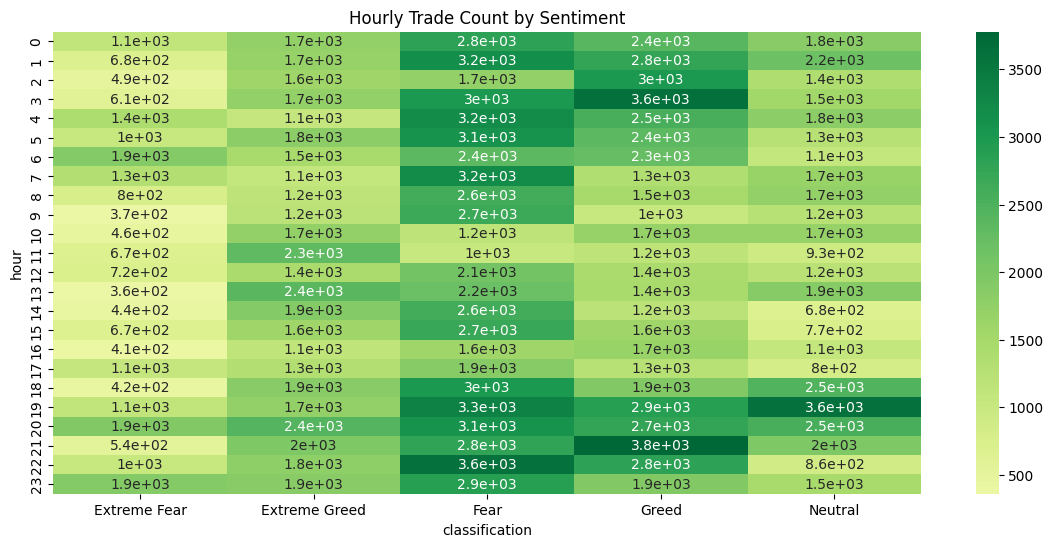

In [5]:
hour_trade_count = trade_history.pivot_table(
    values='Trade ID',
    index='hour',
    columns='classification',
    aggfunc='count'
)

# hour_trade_count

plt.figure(figsize=(14,6))

sns.heatmap(
    hour_trade_count,
    cmap='RdYlGn',
    center=0,
    annot=True
)

plt.title("Hourly Trade Count by Sentiment")

### Key Insights: Hourly Trade Count by Sentiment

**Fear**
- Dominated trading activity across most hours.
- Peak activity:
  - `22:00` → **3.6K trades**
  - `19:00` → **3.3K trades**
  - `01:00` & `04:00` → **3.2K trades**

**Greed**
- Highest activity occurred during:
  - `03:00` → **3.6K trades**
  - `21:00` → **3.8K trades** (highest overall)

**Extreme Greed**
- Activity peaked during:
  - `13:00` → **2.4K trades**
  - `19:00` → **2.4K trades**

**Neutral**
- Highest participation:
  - `19:00` → **3.6K trades**
  - `18:00` → **2.5K trades**

**Extreme Fear**
- Lowest participation overall among all sentiment regimes.
- Peak activity:
  - `06:00` → **1.9K trades**
  - `23:00` → **1.9K trades**

- Trading activity intensified significantly during Fear and Greed conditions compared to Neutral and Extreme Fear states.
- Late evening hours (`19:00–23:00`) showed the highest overall market participation across multiple sentiment regimes.

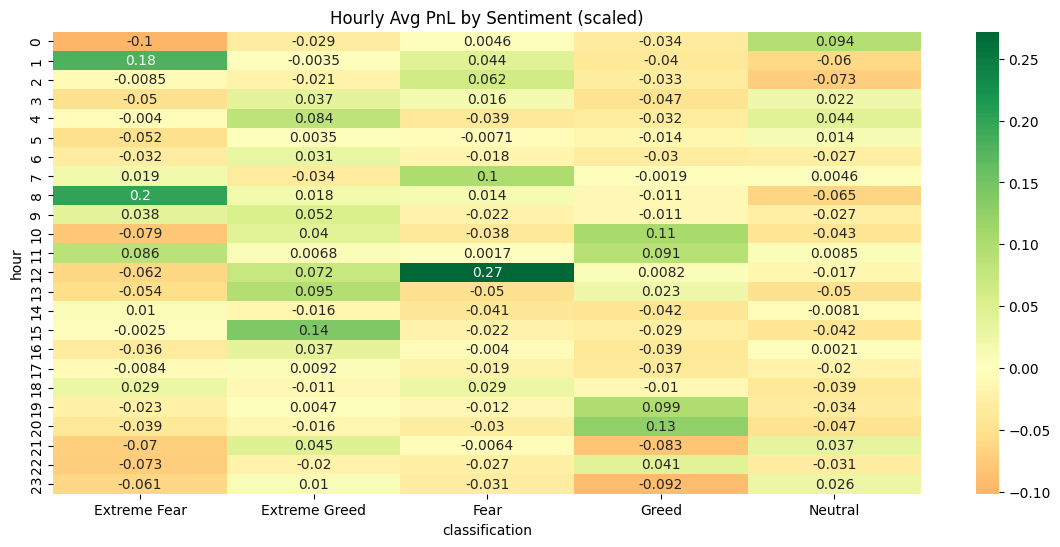

In [6]:
day_profit_pivot = trade_history.pivot_table(
    values='Scaled PnL',
    index='hour',
    columns='classification',
    aggfunc='mean'
)

plt.figure(figsize=(14,6))

sns.heatmap(
    day_profit_pivot,
    cmap='RdYlGn',
    center=0,
    annot=True
)

plt.title("Hourly Avg PnL by Sentiment (scaled)")
plt.show()

# Key Insights: Hourly Avg PnL by Sentiment

## Extreme Fear
- Highest profitability occurred at:
  - `08:00` → **0.20 scaled avg pnl**
  - `01:00` → **0.18**
- Lowest profitability:
  - `00:00` → **-0.10**
  - `23:00` → **-0.061**

## Extreme Greed
- Strongest pnl observed during:
  - `15:00` → **0.14**
  - `13:00` → **0.095**
- Weakest performance:
  - `14:00` → **-0.16**

## Fear
- `12:00` showed the highest profitability across all sentiment regimes:
  - **0.27 scaled avg pnl**
- Additional profitable periods:
  - `07:00` → **0.10**
  - `02:00` → **0.062**

## Greed
- Peak profitability:
  - `20:00` → **0.13**
  - `10:00` → **0.11**
- Weakest periods:
  - `21:00` → **-0.083**
  - `23:00` → **-0.092**

## Neutral
- Highest profitability:
  - `00:00` → **0.094**
- Lowest profitability:
  - `02:00` → **-0.073**
  - `08:00` → **-0.065**

- Fear-based trading exhibited the strongest profitability concentration overall, especially during midday hours.
- Greed-related profitability showed higher intraday volatility compared to Neutral sentiment conditions.